In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image = cv2.imread("raw_captures/document.jpeg")

In [3]:
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

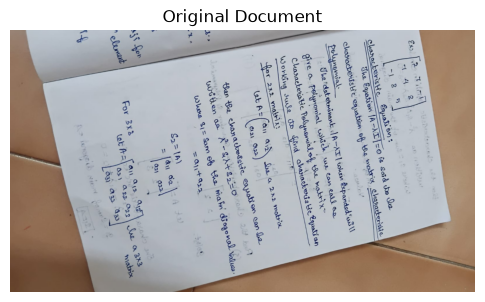

In [4]:
plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("Original Document")
plt.axis("off")
plt.show()

Prediction

I expect the Bilateral Filter to preserve the text edges the best because it smooths the image while keeping edges sharp. Mean and Gaussian filters may blur the text, while the Median filter is generally better for salt-and-pepper noise than Gaussian noise.

In [5]:
mean = 0
sigma = 25

noise = np.random.normal(mean, sigma, image.shape).astype(np.float32)

noisy = image.astype(np.float32) + noise

noisy = np.clip(noisy, 0, 255).astype(np.uint8)

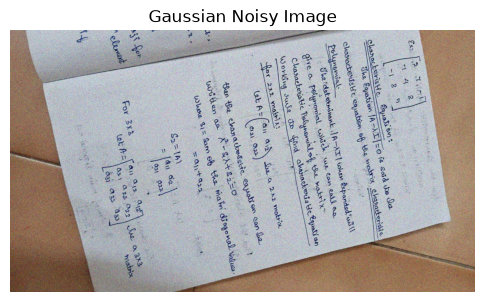

In [6]:
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB))
plt.title("Gaussian Noisy Image")
plt.axis("off")
plt.show()

In [7]:
mean_filter = cv2.blur(noisy, (5,5))

In [8]:
gaussian_filter = cv2.GaussianBlur(noisy, (5,5), 0)

In [9]:
median_filter = cv2.medianBlur(noisy, 5)

In [10]:
bilateral_filter = cv2.bilateralFilter(noisy, 9, 75, 75)

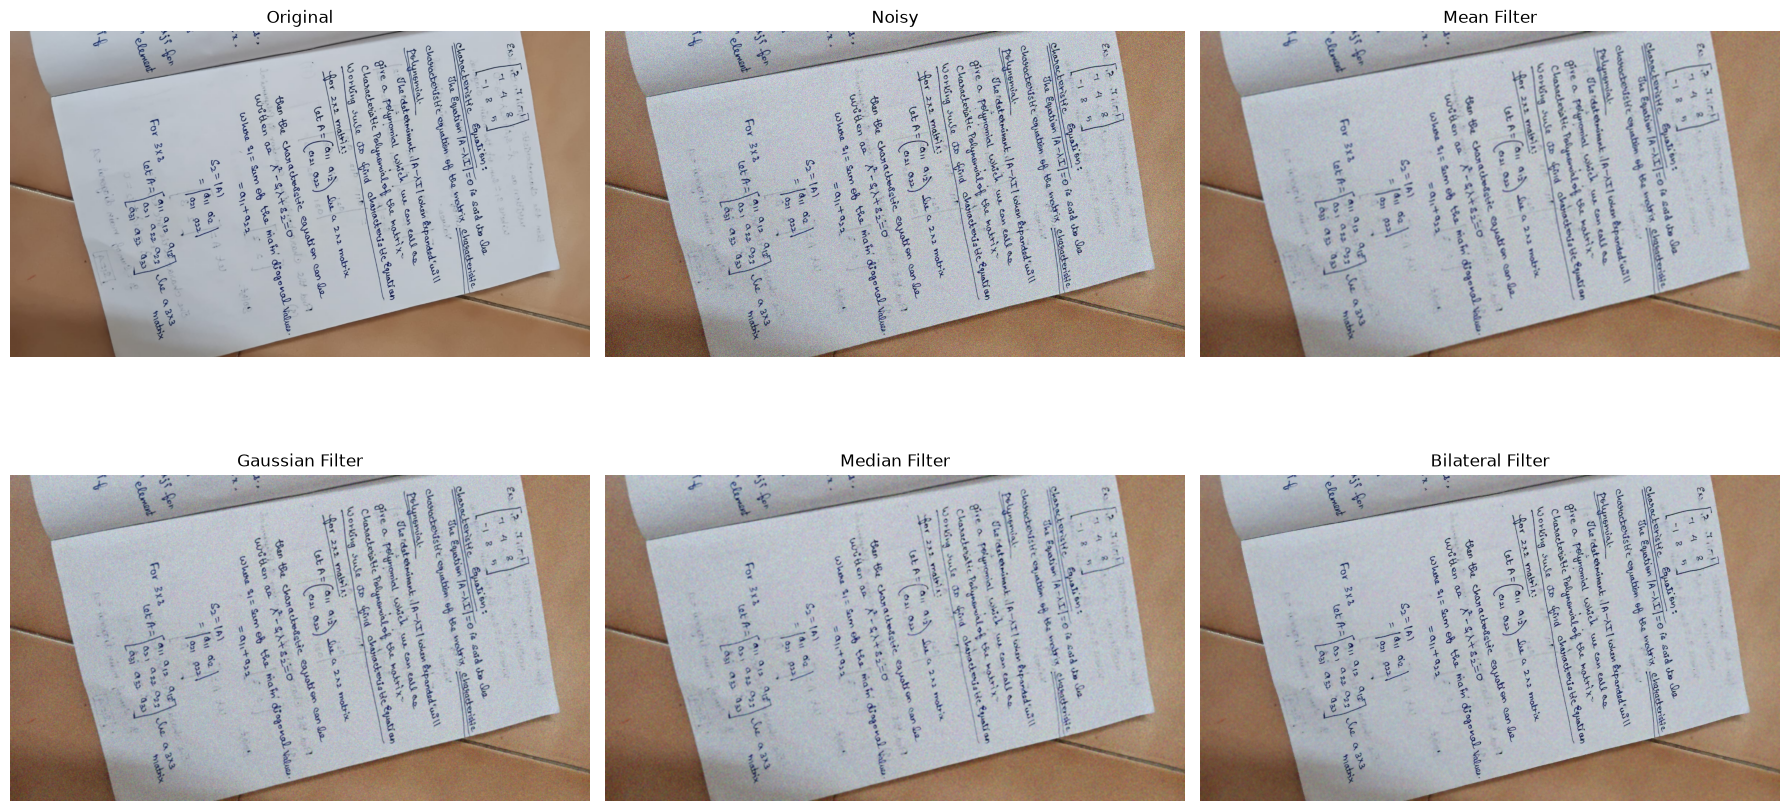

In [11]:
plt.figure(figsize=(18,10))

plt.subplot(2,3,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB))
plt.title("Noisy")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(cv2.cvtColor(mean_filter, cv2.COLOR_BGR2RGB))
plt.title("Mean Filter")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(cv2.cvtColor(gaussian_filter, cv2.COLOR_BGR2RGB))
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(cv2.cvtColor(median_filter, cv2.COLOR_BGR2RGB))
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(cv2.cvtColor(bilateral_filter, cv2.COLOR_BGR2RGB))
plt.title("Bilateral Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

Observation

After comparing all four filters, the Bilateral Filter preserved the text edges the best while reducing Gaussian noise. The Mean and Gaussian filters smoothed the image but also blurred the handwritten text. The Median filter preserved edges better than the Mean filter but was less effective than the Bilateral filter for this type of noise.My prediction was correct because the Bilateral Filter reduced noise while maintaining the sharpness of the handwritten characters.